# Collective States via HMM — Updated Overlap Labels

**Objective:** Reproduce HMM analysis with updated transcript overlap data, refit on the corrected `collective_features_v20260905` matrix (T0-baseline fix, discussion-only filtering, whitespace-parsing bugfix — see `docs/feature_catalog.md` changelog 2026-09-05).

**Key Change:** `tr_competitive_overlap` now includes 52 previously `needs_review` entries.

**Method:** Gaussian HMM + BIC selection (k=2-6) on 10 diagnostic-cleaned features, matching the primary HMM candidate families in `docs/thesis_research_questions.md` §6 (group physiology, pupil, conversation structure — no audio, no self-report).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

print("✓ Imports loaded")

✓ Imports loaded


## 1. Load & Preprocess Data

In [2]:
# Load corrected group-window matrix (all 10 groups) — v20260905: T0-baseline fix, discussion-only filtering, whitespace bugfix
COLLECTIVE_DIR = 'results/collective_features_v20260905'
windows = pd.read_csv(f'{COLLECTIVE_DIR}/collective_window_features.tsv', sep='\t')
print(f'✓ Loaded {len(windows)} windows, {windows["group_id"].nunique()} groups  (source: {COLLECTIVE_DIR})')

# Filter to T1-T3 with transcript data
data = windows[windows['task_id'].isin(['T1','T2','T3'])].copy()
data = data.dropna(subset=['tr_spk_duration_s'])
print(f'✓ Filtered to {len(data)} transcript-covered windows (T1-T3)')
print(f'  Groups: {sorted(data["group_id"].unique())}')

✓ Loaded 1419 windows, 10 groups  (source: results/collective_features_v20260905)
✓ Filtered to 616 transcript-covered windows (T1-T3)
  Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']


## 2. Apply Diagnostic Fixes (10 clean features)

In [3]:
data_clean = data.copy()

# Fix 1: Within-group z-score physio features
PHYSIO_Z = ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean',
            'group_et_pupil_mean_mean']
for col in PHYSIO_Z:
    if col in data_clean.columns:
        data_clean[col] = data_clean.groupby('group_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))

# Fix 2: Log transform skewed counts
LOG_FEATS = ['tr_silence_duration_s', 'tr_overlap_count', 'tr_competitive_overlap',
             'tr_laughter_count', 'tr_overlap_time_s']
for col in LOG_FEATS:
    if col in data_clean.columns:
        data_clean[col] = np.log1p(data_clean[col].clip(lower=0))

# Define clean feature set (10 features)
CLEAN_FEATS = [
    'group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean',
    'tr_silence_duration_s', 'tr_backchannel_count', 'tr_overlap_count',
    'tr_competitive_overlap', 'tr_laughter_count', 'tr_n_active_speakers',
    'group_et_pupil_mean_mean'
]

CLEAN_LABELS = [
    'HR (z)', 'EDA phasic (z)', 'Temp (z)',
    'Silence [log]', 'Backchannels [log]', 'Overlaps [log]',
    'Competitive OVL [log] ★', 'Laughter [log]', 'Active speakers',
    'Pupil diam (z)'
]

print(f'✓ Clean feature set ({len(CLEAN_FEATS)} features):')
for c, l in zip(CLEAN_FEATS, CLEAN_LABELS):
    print(f'  {l}')

✓ Clean feature set (10 features):
  HR (z)
  EDA phasic (z)
  Temp (z)
  Silence [log]
  Backchannels [log]
  Overlaps [log]
  Competitive OVL [log] ★
  Laughter [log]
  Active speakers
  Pupil diam (z)


## 3. PCA & Sequence Building

In [4]:
# Standardize
X_all = SimpleImputer(strategy='mean').fit_transform(data_clean[CLEAN_FEATS])
X_all = StandardScaler().fit_transform(X_all)
print(f'✓ Standardized matrix: {X_all.shape}')

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_all)
n80 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1
X_pca_80 = X_pca[:, :n80]

print(f'\n📊 PCA: {n80} components explain 80% variance')
for i in range(min(5, n80)):
    print(f'  PC{i+1}: {pca.explained_variance_ratio_[i]:.1%}')

# Build sequences (one per group × task, sorted by window_index)
sequences_meta = []
sequences_X = []

for (grp, task), sub in data_clean.groupby(['group_id', 'task_id']):
    sub_sorted = sub.sort_values('window_index')
    if len(sub_sorted) < 4:
        continue
    arr = X_pca_80[sub_sorted.index.map(lambda i: np.where(data_clean.index == i)[0][0])]
    sequences_X.append(arr)
    sequences_meta.append({'group_id': grp, 'task_id': task, 'n_windows': len(sub_sorted)})

print(f'\n✓ Sequences built: {len(sequences_X)}')
print(f'  Lengths: min={min(len(s) for s in sequences_X)}, max={max(len(s) for s in sequences_X)}, '
      f'mean={np.mean([len(s) for s in sequences_X]):.1f}')

✓ Standardized matrix: (616, 10)

📊 PCA: 6 components explain 80% variance
  PC1: 30.2%
  PC2: 12.8%
  PC3: 10.2%
  PC4: 9.8%
  PC5: 9.2%

✓ Sequences built: 28
  Lengths: min=13, max=34, mean=22.0


## 4. Define & Fit Gaussian HMM

In [5]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

class GaussianHMM:
    """Diagonal-covariance Gaussian HMM with Baum-Welch EM."""
    
    def __init__(self, n_states=3, n_iter=100, tol=1e-4, random_state=42):
        self.K = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
    
    def _log_emit(self, X):
        T, D = X.shape
        log_p = np.zeros((T, self.K))
        for k in range(self.K):
            log_p[:, k] = multivariate_normal.logpdf(X, mean=self.means_[k],
                                                      cov=np.diag(self.covs_[k]))
        return log_p
    
    def _forward(self, log_emit):
        T, K = log_emit.shape
        log_alpha = np.full((T, K), -np.inf)
        log_alpha[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        log_A = np.log(self.A_ + 1e-300)
        for t in range(1, T):
            for k in range(K):
                log_alpha[t, k] = logsumexp(log_alpha[t-1] + log_A[:, k]) + log_emit[t, k]
        return log_alpha
    
    def _backward(self, log_emit):
        T, K = log_emit.shape
        log_beta = np.zeros((T, K))
        log_A = np.log(self.A_ + 1e-300)
        for t in range(T-2, -1, -1):
            for k in range(K):
                log_beta[t, k] = logsumexp(log_A[k] + log_emit[t+1] + log_beta[t+1])
        return log_beta
    
    def _viterbi(self, log_emit):
        T, K = log_emit.shape
        log_A = np.log(self.A_ + 1e-300)
        delta = np.full((T, K), -np.inf)
        psi = np.zeros((T, K), dtype=int)
        delta[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        for t in range(1, T):
            for k in range(K):
                scores = delta[t-1] + log_A[:, k]
                psi[t, k] = np.argmax(scores)
                delta[t, k] = scores[psi[t, k]] + log_emit[t, k]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path
    
    def fit(self, sequences):
        D = sequences[0].shape[1]
        K = self.K
        all_X = np.vstack(sequences)
        km = KMeans(n_clusters=K, random_state=self.rng.integers(0, 2**31 - 1), n_init=10)
        labels = km.fit_predict(all_X)
        self.means_ = km.cluster_centers_.copy()
        self.covs_ = np.array([np.var(all_X[labels==k], axis=0).clip(1e-4) for k in range(K)])
        self.pi_ = np.ones(K) / K
        self.A_ = np.ones((K, K)) / K
        
        prev_ll = -np.inf
        for iteration in range(self.n_iter):
            pi_num, A_num = np.zeros(K), np.zeros((K, K))
            mean_num = np.zeros((K, D))
            weight_s, total_ll = np.zeros(K), 0.0
            gammas = []  # cached so the variance M-step below can use the *new* mean, not the old one
            
            for X in sequences:
                T = len(X)
                if T < 2:
                    gammas.append(None)
                    continue
                log_e = self._log_emit(X)
                log_a = self._forward(log_e)
                log_b = self._backward(log_e)
                ll = logsumexp(log_a[-1])
                total_ll += ll
                
                log_gamma = log_a + log_b
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)
                gammas.append(gamma)
                
                log_A = np.log(self.A_ + 1e-300)
                log_xi = (log_a[:-1, :, None] + log_A[None, :, :] + log_e[1:, None, :] + log_b[1:, None, :])
                log_xi -= logsumexp(log_xi.reshape(T-1, -1), axis=1, keepdims=True).reshape(T-1, 1, 1)
                xi = np.exp(log_xi)
                
                pi_num += gamma[0]
                A_num += xi.sum(axis=0)
                weight_s += gamma.sum(axis=0)
                mean_num += gamma.T @ X
            
            self.pi_ = np.maximum(pi_num / pi_num.sum(), 1e-10)
            self.A_ = np.maximum(A_num / A_num.sum(axis=1, keepdims=True), 1e-10)
            new_means = self.means_.copy()
            for k in range(K):
                if weight_s[k] > 1e-6:
                    new_means[k] = mean_num[k] / weight_s[k]
            
            # Exact M-step: accumulate variance around the newly updated mean (not last iteration's).
            cov_num = np.zeros((K, D))
            for X, gamma in zip(sequences, gammas):
                if gamma is None:
                    continue
                for k in range(K):
                    cov_num[k] += (gamma[:, k:k+1] * (X - new_means[k])**2).sum(axis=0)
            
            self.means_ = new_means
            for k in range(K):
                if weight_s[k] > 1e-6:
                    self.covs_[k] = np.maximum(cov_num[k] / weight_s[k], 1e-4)
            
            if abs(total_ll - prev_ll) < self.tol:
                break
            prev_ll = total_ll
        
        self.log_likelihood_ = total_ll
        return self
    
    def bic(self, sequences):
        D = sequences[0].shape[1]
        N = sum(len(s) for s in sequences)
        # K-1 free params per transition-matrix row (each row sums to 1), matching the pi_ constraint below.
        n_params = self.K * (D + D + (self.K - 1)) + (self.K - 1)
        return -2 * self.log_likelihood_ + n_params * np.log(N)
    
    def decode(self, X):
        return self._viterbi(self._log_emit(X))

print('✓ GaussianHMM class defined (BIC param-count fix + exact-mean variance M-step)')


✓ GaussianHMM class defined (BIC param-count fix + exact-mean variance M-step)


## 5. BIC Selection (k=2-6)

  k=2  BIC=10714.6  logL=-5270.6  (seed range 10714.6-10714.6)
  k=3  BIC=10311.1  logL=-5014.2  (seed range 10311.1-10311.1)
  k=4  BIC=10267.1  logL=-4931.2  (seed range 10267.1-10267.1)
  k=5  BIC=10050.9  logL=-4755.7  (seed range 10050.9-10050.9)
  k=6  BIC=10047.2  logL=-4680.0  (seed range 10047.2-10047.2)

🎯 Best k by BIC: 6


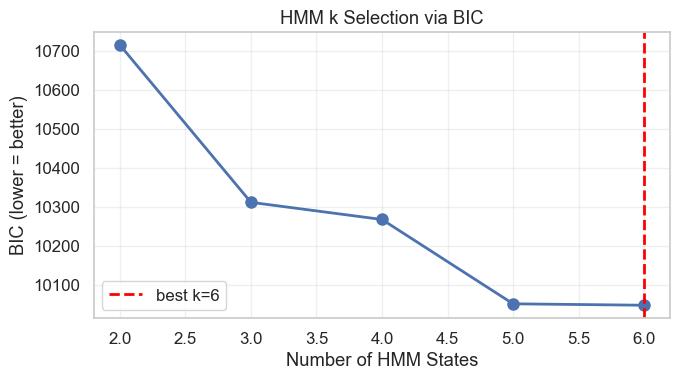

✓ Saved BIC plot to results/hmm_states_v20260905/hmm_bic_selection.png


In [6]:
hmm_bics = {}
hmm_models = {}
hmm_bic_seed_spread = {}

for k in range(2, 7):
    bics_run = []
    for seed in [42, 7, 99]:
        m = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
        m.fit(sequences_X)
        bics_run.append((m.bic(sequences_X), m))
    best_bic, best_m = min(bics_run, key=lambda x: x[0])
    hmm_bics[k] = best_bic
    hmm_models[k] = best_m
    seed_bics = [b for b, _ in bics_run]
    hmm_bic_seed_spread[k] = (min(seed_bics), max(seed_bics))
    print(f"  k={k}  BIC={best_bic:.1f}  logL={best_m.log_likelihood_:.1f}  (seed range {min(seed_bics):.1f}-{max(seed_bics):.1f})")

best_k_hmm = min(hmm_bics, key=hmm_bics.get)
print(f"\n🎯 Best k by BIC: {best_k_hmm}")

# Plot BIC curve
fig, ax = plt.subplots(figsize=(7, 4))
ks = sorted(hmm_bics.keys())
ax.plot(ks, [hmm_bics[k] for k in ks], 'o-', linewidth=2, markersize=8)
ax.axvline(best_k_hmm, ls='--', color='red', lw=2, label=f'best k={best_k_hmm}')
ax.set_xlabel('Number of HMM States'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('HMM k Selection via BIC'); ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
OUT_DIR = 'results/hmm_states_v20260905'
import os
os.makedirs(OUT_DIR, exist_ok=True)
plt.savefig(f'{OUT_DIR}/hmm_bic_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Saved BIC plot to {OUT_DIR}/hmm_bic_selection.png')

## 6. Decode States & Assign to Data

In [7]:
best_hmm = hmm_models[best_k_hmm]
K_HMM = best_k_hmm

hmm_state_col = np.full(len(data_clean), -1, dtype=int)

for meta, seq in zip(sequences_meta, sequences_X):
    grp, task = meta['group_id'], meta['task_id']
    path = best_hmm.decode(seq)
    sub_idx = data_clean[(data_clean['group_id']==grp) & (data_clean['task_id']==task)].sort_values('window_index').index
    hmm_state_col[data_clean.index.get_indexer(sub_idx)] = path

data_clean['hmm_state'] = hmm_state_col
valid = data_clean['hmm_state'] >= 0

print(f'✓ Windows with HMM state assigned: {valid.sum()} / {len(data_clean)}')
print(f'\nState distribution:')
for state_id in range(K_HMM):
    count = (data_clean['hmm_state'] == state_id).sum()
    pct = count / valid.sum() * 100
    print(f'  State {state_id}: {count:3d} windows ({pct:5.1f}%)')

✓ Windows with HMM state assigned: 616 / 616

State distribution:
  State 0: 114 windows ( 18.5%)
  State 1: 110 windows ( 17.9%)
  State 2: 110 windows ( 17.9%)
  State 3: 111 windows ( 18.0%)
  State 4:  85 windows ( 13.8%)
  State 5:  86 windows ( 14.0%)


## 7. State Profiles & Transitions

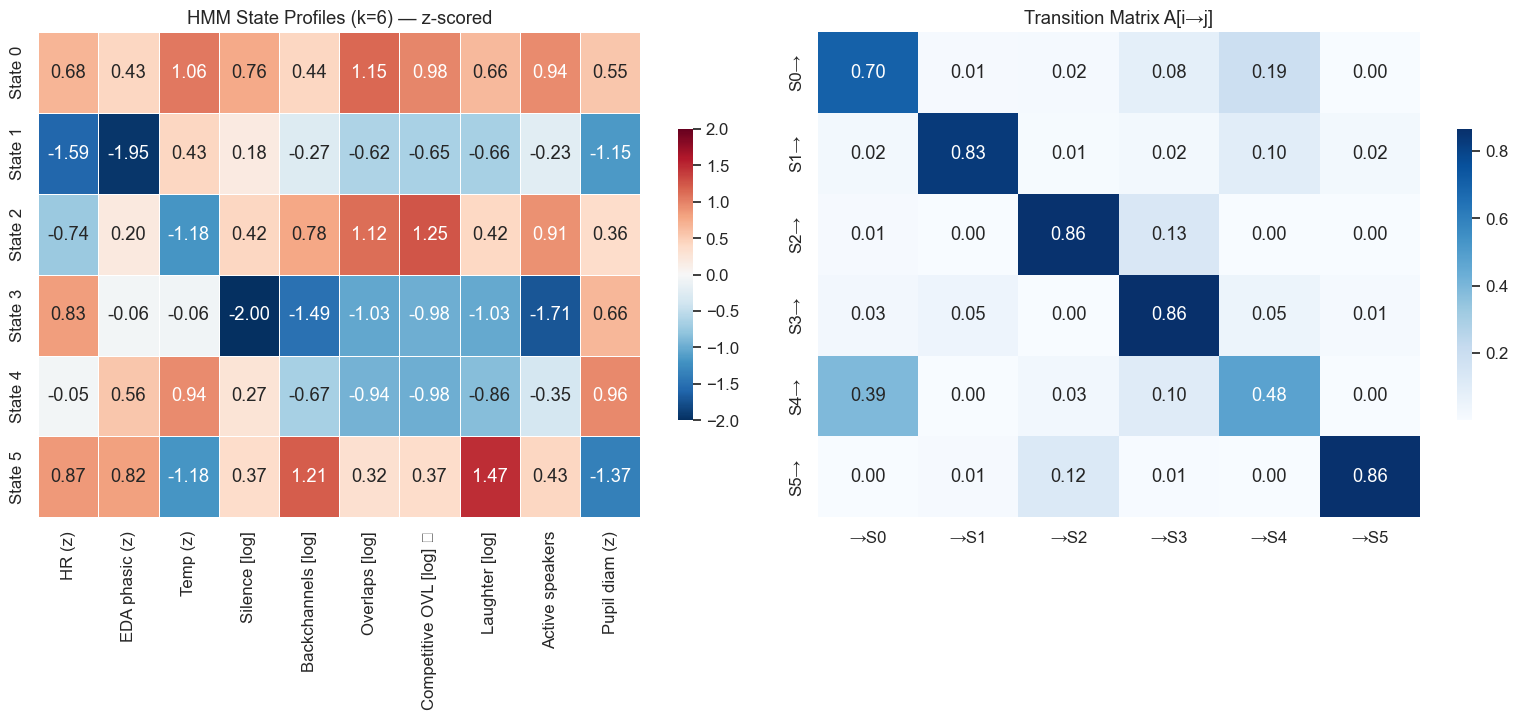

✓ Saved profile heatmap to results/hmm_states_v20260905/hmm_profiles_transitions.png


In [8]:
dc_valid = data_clean[valid].copy()

prof_hmm = dc_valid.groupby('hmm_state')[CLEAN_FEATS].mean()
prof_hmm.index = [f'State {i}' for i in prof_hmm.index]
prof_hmm_z = (prof_hmm - prof_hmm.mean()) / (prof_hmm.std() + 1e-9)
prof_hmm_z.columns = CLEAN_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, K_HMM*0.9 + 2))

sns.heatmap(prof_hmm_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[0], vmin=-2, vmax=2, cbar_kws={'shrink': 0.6})
axes[0].set_title(f'HMM State Profiles (k={K_HMM}) — z-scored')

A = best_hmm.A_
sns.heatmap(A, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'→S{k}' for k in range(K_HMM)],
            yticklabels=[f'S{k}→' for k in range(K_HMM)],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('Transition Matrix A[i→j]')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/hmm_profiles_transitions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Saved profile heatmap to {OUT_DIR}/hmm_profiles_transitions.png')

## 8. Key Change: Competitive Overlap by State

In [9]:
print("=" * 70)
print("KEY CHANGE: tr_competitive_overlap")
print("=" * 70)

# Back to original scale (undo log)
comp_ovl_orig = np.expm1(dc_valid['tr_competitive_overlap'].dropna())

print(f"\n📊 Updated tr_competitive_overlap (ORIGINAL SCALE) by state:")
for state_id in range(K_HMM):
    state_comp = dc_valid[dc_valid['hmm_state'] == state_id]['tr_competitive_overlap'].dropna()
    state_comp_orig = np.expm1(state_comp)
    print(f"  State {state_id}: mean={state_comp_orig.mean():.2f}, median={state_comp_orig.median():.1f}, n={len(state_comp)}")

print(f"\n✓ Includes 52 previously 'needs_review' overlaps + 95+ reclassified entries")

KEY CHANGE: tr_competitive_overlap

📊 Updated tr_competitive_overlap (ORIGINAL SCALE) by state:
  State 0: mean=1.15, median=1.0, n=114
  State 1: mean=0.15, median=0.0, n=110
  State 2: mean=1.44, median=1.0, n=110
  State 3: mean=0.00, median=0.0, n=111
  State 4: mean=0.00, median=0.0, n=85
  State 5: mean=0.84, median=0.0, n=86

✓ Includes 52 previously 'needs_review' overlaps + 95+ reclassified entries


## 9. Summary & Export

In [10]:
print("=" * 70)
print("HMM COLLECTIVE STATES — UPDATED OVERLAP LABELS")
print("=" * 70)

print(f"\n✅ DATA:")
print(f"   Windows: {len(data_clean)}")
print(f"   Valid (with HMM state): {valid.sum()}")
print(f"   Groups: {sorted(data_clean['group_id'].unique())}")
print(f"   Tasks: T1, T2, T3")

print(f"\n✅ PREPROCESSING:")
print(f"   Within-group z-scoring: ✓ (physio + pupil diam)")
print(f"   Log transform: ✓ (skewed counts)")
print(f"   Clean features: {len(CLEAN_FEATS)}")
print(f"   PCA components (80% variance): {n80}")
print(f"   Sequences: {len(sequences_X)}")

print(f"\n✅ HMM RESULTS:")
print(f"   Number of states: {K_HMM}")
print(f"   Selected via: BIC minimization")
print(f"   BIC value: {hmm_bics[K_HMM]:.1f}")
print(f"   Log-likelihood: {best_hmm.log_likelihood_:.1f}")

print(f"\n✅ KEY CHANGE:")
print(f"   tr_competitive_overlap now includes:")
print(f"   • 52 previously 'needs_review' entries")
print(f"   • 95+ 'collaborative' reclassified by duration")
print(f"   • Method: Timing-based (no semantic labeling)")

print(f"\n✅ OUTPUT:")
print(f"   Figure: {OUT_DIR}/hmm_bic_selection.png")
print(f"   Figure: {OUT_DIR}/hmm_profiles_transitions.png")

print(f"\n💾 Ready for comparison with paper draft!")

HMM COLLECTIVE STATES — UPDATED OVERLAP LABELS

✅ DATA:
   Windows: 616
   Valid (with HMM state): 616
   Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
   Tasks: T1, T2, T3

✅ PREPROCESSING:
   Within-group z-scoring: ✓ (physio + pupil diam)
   Log transform: ✓ (skewed counts)
   Clean features: 10
   PCA components (80% variance): 6
   Sequences: 28

✅ HMM RESULTS:
   Number of states: 6
   Selected via: BIC minimization
   BIC value: 10047.2
   Log-likelihood: -4680.0

✅ KEY CHANGE:
   tr_competitive_overlap now includes:
   • 52 previously 'needs_review' entries
   • 95+ 'collaborative' reclassified by duration
   • Method: Timing-based (no semantic labeling)

✅ OUTPUT:
   Figure: results/hmm_states_v20260905/hmm_bic_selection.png
   Figure: results/hmm_states_v20260905/hmm_profiles_transitions.png

💾 Ready for comparison with paper draft!


In [11]:
# Export per-window cluster assignments (versioned, does not overwrite the pre-refit file)
export = dc_valid[['group_id', 'task_id', 'window_index', 'hmm_state']].copy()
export.to_csv(f'{OUT_DIR}/hmm_window_state_assignments.tsv', sep='\t', index=False)
print(f"✓ Exported {len(export)} window-level state assignments to {OUT_DIR}/hmm_window_state_assignments.tsv")
print(f"\nState distribution:")
print(export['hmm_state'].value_counts().sort_index())

✓ Exported 616 window-level state assignments to results/hmm_states_v20260905/hmm_window_state_assignments.tsv

State distribution:
hmm_state
0    114
1    110
2    110
3    111
4     85
5     86
Name: count, dtype: int64


## 10. Group-Task State Occupancy (for prediction models)

In [12]:
# Group-task occupancy proportions — the input the prediction notebooks need (S{k}_pct columns)
occ = (export.groupby(['group_id', 'task_id', 'hmm_state']).size()
       .unstack('hmm_state', fill_value=0))
occ = occ.reindex(columns=range(K_HMM), fill_value=0)
n_windows = occ.sum(axis=1)
occ_pct = occ.div(n_windows, axis=0)
occ_pct.columns = [f'S{k}_pct' for k in occ_pct.columns]
occ_pct = occ_pct.reset_index()
occ_pct['n_windows'] = n_windows.values
occ_pct = occ_pct.rename(columns={'task_id': 'task'})

occ_pct.to_csv(f'{OUT_DIR}/hmm_state_proportions_task.tsv', sep='\t', index=False)
print(f"✓ Exported {len(occ_pct)} group-task state-proportion rows to {OUT_DIR}/hmm_state_proportions_task.tsv")
occ_pct.head()

✓ Exported 28 group-task state-proportion rows to results/hmm_states_v20260905/hmm_state_proportions_task.tsv


,group_id,task,S0_pct,S1_pct,S2_pct,S3_pct,S4_pct,S5_pct,n_windows
0,grp-07,T1,0.000000,0.000000,0.384615,0.307692,0.000000,0.307692,13
1,grp-07,T2,0.483871,0.129032,0.000000,0.096774,0.290323,0.000000,31
2,grp-07,T3,0.000000,0.000000,0.705882,0.176471,0.000000,0.117647,17
3,grp-08,T1,0.346154,0.192308,0.000000,0.269231,0.192308,0.000000,26
4,grp-08,T2,0.382353,0.176471,0.000000,0.147059,0.294118,0.000000,34


## 10b. State Trajectories per Group (exploratory)

Descriptive only — not an input to any prediction model and not a claim requiring LOGO/L2GO validation. Shows how each group's decoded HMM state evolves within and across T1/T2/T3, using the states fit on all 10 groups (\Cref{subsec:hmm-summaries}).

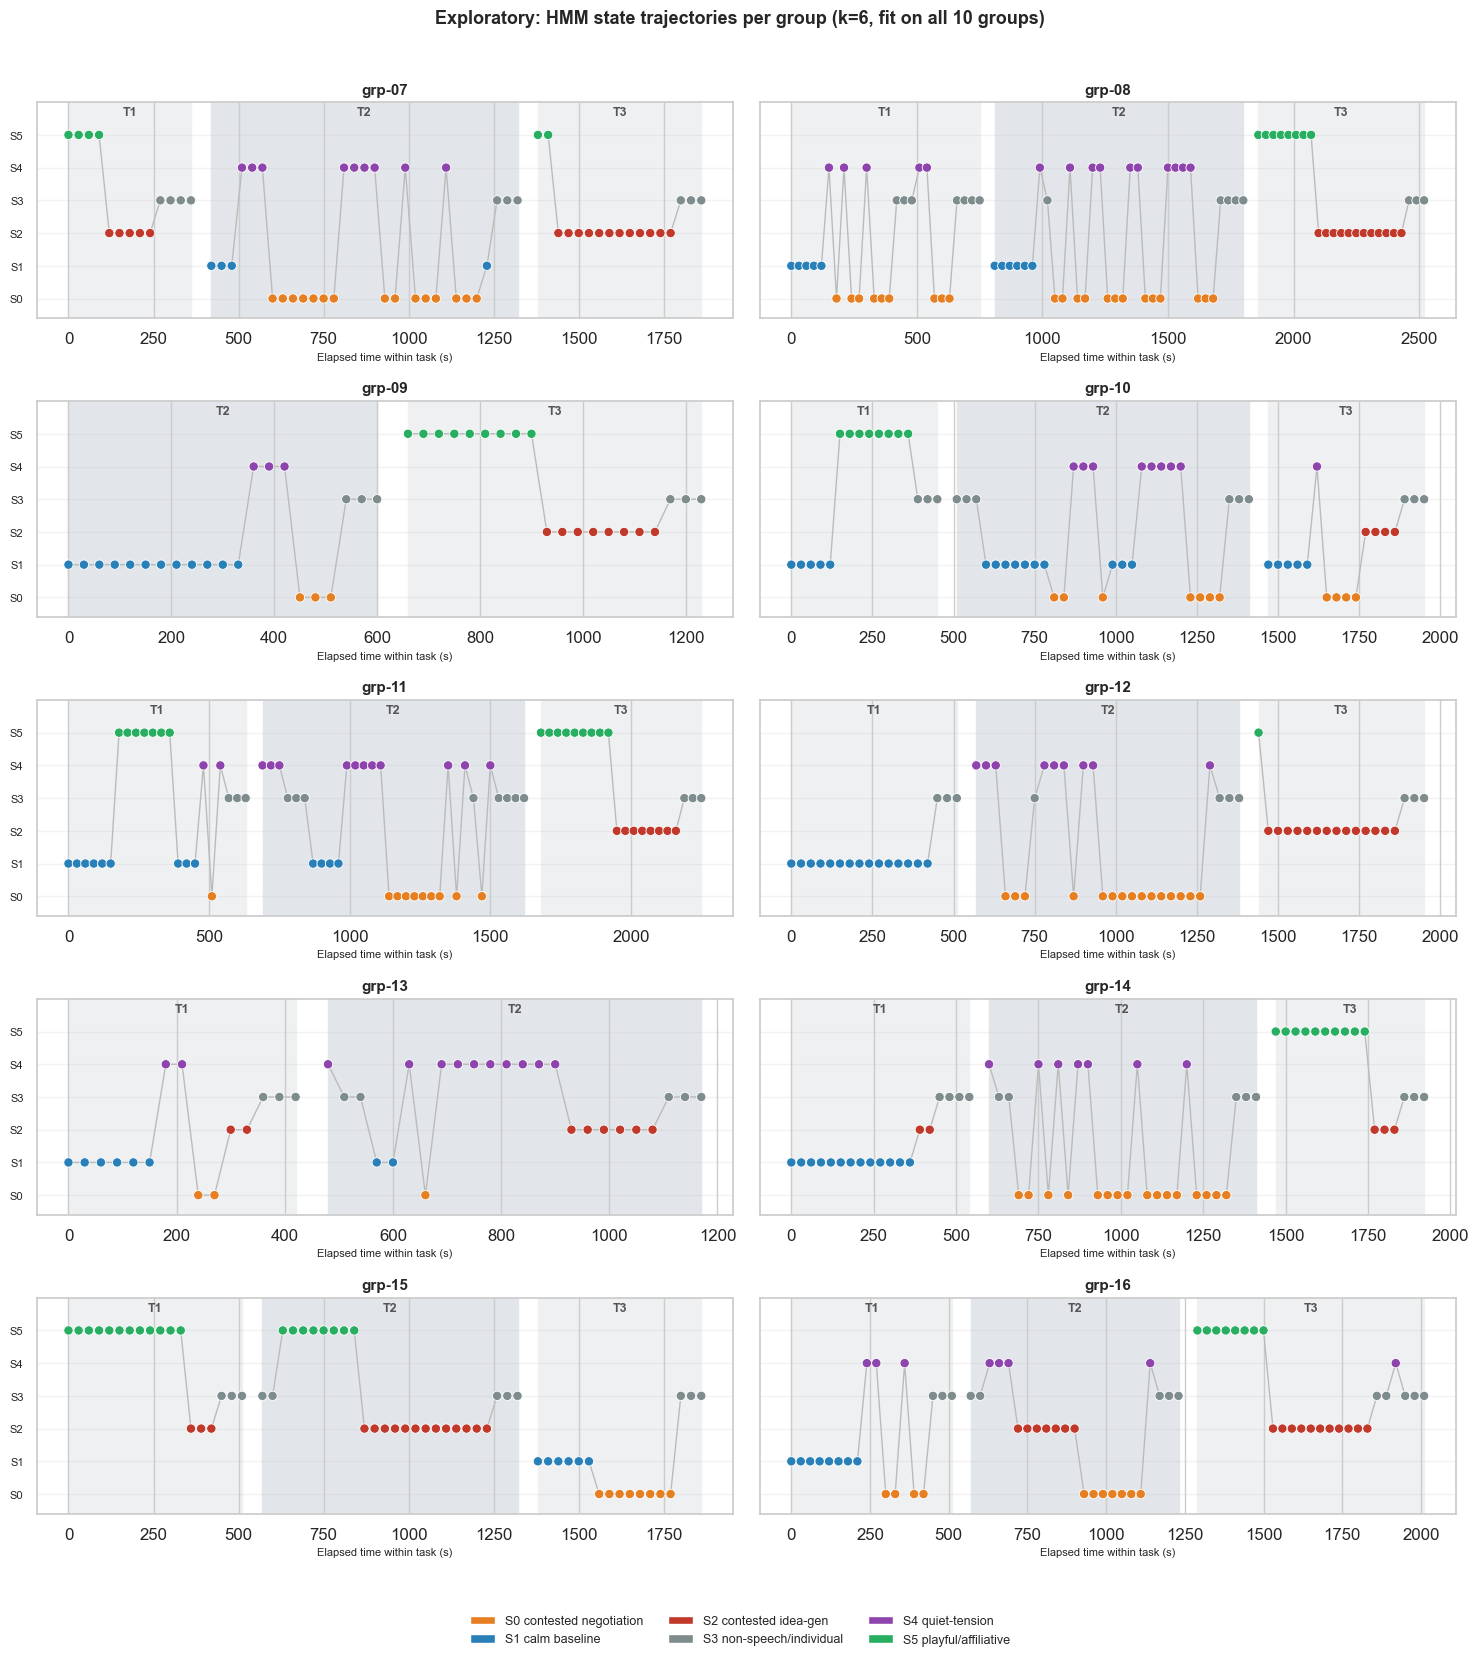

✓ Saved results/hmm_states_v20260905/hmm_state_trajectories_per_group.png


In [24]:
from matplotlib.patches import Patch

STATE_COLORS = {0: '#e67e22', 1: '#2980b9', 2: '#c0392b', 3: '#7f8c8d', 4: '#8e44ad', 5: '#27ae60'}
STATE_LABELS = {
    0: 'S0 contested negotiation', 1: 'S1 calm baseline', 2: 'S2 contested idea-gen',
    3: 'S3 non-speech/individual', 4: 'S4 quiet-tension', 5: 'S5 playful/affiliative',
}
TASK_ORDER = ['T1', 'T2', 'T3']
TASK_GAP_S = 60.0  # visual gap (seconds) between tasks on the shared per-group x-axis

export_traj = dc_valid[['group_id', 'task_id', 'window_index', 'window_start_s', 'hmm_state']].copy()
group_ids = sorted(export_traj['group_id'].unique())

fig, axes = plt.subplots(5, 2, figsize=(15, 16), sharey=True)
axes = axes.flatten()

for idx, grp in enumerate(group_ids):
    ax = axes[idx]
    g = export_traj[export_traj['group_id'] == grp]
    x_offset = 0.0
    task_bounds = []
    for task in TASK_ORDER:
        t = g[g['task_id'] == task].sort_values('window_start_s')
        if t.empty:
            continue
        t_rel = t['window_start_s'] - t['window_start_s'].min()
        x = x_offset + t_rel
        ax.axvspan(x_offset, x.max(), color='#eef0f2' if task != 'T2' else '#e2e5e9', zorder=0)
        ax.plot(x, t['hmm_state'], '-', color='#bbbbbb', linewidth=1, zorder=1)
        ax.scatter(x, t['hmm_state'], c=[STATE_COLORS[s] for s in t['hmm_state']],
                   s=45, edgecolors='white', linewidths=0.6, zorder=2)
        task_bounds.append((task, x_offset, x.max()))
        x_offset = x.max() + TASK_GAP_S

    for task, x0, x1 in task_bounds:
        ax.text((x0 + x1) / 2, K_HMM - 0.4, task, ha='center', fontsize=9,
                fontweight='bold', color='#555555')

    ax.set_title(grp, fontsize=11, fontweight='bold')
    ax.set_ylim(-0.6, K_HMM)
    ax.set_yticks(range(K_HMM))
    ax.set_yticklabels([f'S{k}' for k in range(K_HMM)], fontsize=8)
    ax.set_xlabel('Elapsed time within task (s)', fontsize=8)
    ax.grid(axis='y', alpha=0.25, zorder=0)

legend_patches = [Patch(facecolor=STATE_COLORS[k], edgecolor='white', label=v)
                  for k, v in STATE_LABELS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
fig.suptitle(f'Exploratory: HMM state trajectories per group (k={K_HMM}, fit on all 10 groups)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'{OUT_DIR}/hmm_state_trajectories_per_group.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved {OUT_DIR}/hmm_state_trajectories_per_group.png")

## 11. Alternative Representations — Library HMM, K-Means, Continuous PCA

Sanity-checks for the hand-rolled HMM and tests of whether temporal/Markov structure adds value over simpler representations:
- **hmmlearn** library `GaussianHMM` refit (bug-check against the custom implementation)
- **K-Means** clustering on the same pooled PCA features, ignoring window order (no-temporal-structure ablation)
- **Continuous PCA** per-group-task summary (no discretization at all)

All three export new versioned files under `OUT_DIR` and do not overwrite the existing HMM-state outputs.


In [13]:
# --- hmmlearn library cross-check (bug-check vs hand-rolled implementation) ---
try:
    from hmmlearn.hmm import GaussianHMM as HmmlearnGaussianHMM
    HMMLEARN_AVAILABLE = True
except ImportError:
    HMMLEARN_AVAILABLE = False
    print('⚠ hmmlearn not installed (no prebuilt wheel for this Python version; ' \
          'building from source needs a C++ compiler that is not available here). Skipping library cross-check.')

if HMMLEARN_AVAILABLE:
    from scipy.optimize import linear_sum_assignment
    lengths = [len(s) for s in sequences_X]
    X_concat = np.vstack(sequences_X)
    lib_hmm = HmmlearnGaussianHMM(n_components=K_HMM, covariance_type='diag',
                                   n_iter=200, tol=1e-5, random_state=42)
    lib_hmm.fit(X_concat, lengths=lengths)
    lib_states = lib_hmm.predict(X_concat, lengths=lengths)
    print(f'✓ hmmlearn logL={lib_hmm.score(X_concat, lengths=lengths):.1f}  '
          f'vs hand-rolled logL={best_hmm.log_likelihood_:.1f}')

    dc_valid['hmmlearn_state'] = lib_states
    export_lib = dc_valid[['group_id', 'task_id', 'window_index', 'hmmlearn_state']].copy()
    export_lib.to_csv(f'{OUT_DIR}/hmmlearn_window_state_assignments.tsv', sep='\t', index=False)

    occ_lib = (export_lib.groupby(['group_id', 'task_id', 'hmmlearn_state']).size()
               .unstack('hmmlearn_state', fill_value=0))
    occ_lib = occ_lib.reindex(columns=range(K_HMM), fill_value=0)
    n_windows_lib = occ_lib.sum(axis=1)
    occ_lib_pct = occ_lib.div(n_windows_lib, axis=0)
    occ_lib_pct.columns = [f'S{k}_pct' for k in occ_lib_pct.columns]
    occ_lib_pct = occ_lib_pct.reset_index().rename(columns={'task_id': 'task'})
    occ_lib_pct['n_windows'] = n_windows_lib.values
    occ_lib_pct.to_csv(f'{OUT_DIR}/hmmlearn_state_proportions_task.tsv', sep='\t', index=False)
    print(f"✓ Exported hmmlearn-based proportions to {OUT_DIR}/hmmlearn_state_proportions_task.tsv")

    conf_lib = pd.crosstab(dc_valid['hmm_state'], dc_valid['hmmlearn_state']).values
    row_ind, col_ind = linear_sum_assignment(-conf_lib)
    agree_lib = conf_lib[row_ind, col_ind].sum() / conf_lib.sum()
    print(f'✓ Best-match window-level agreement between hand-rolled and hmmlearn HMM: {agree_lib:.1%}')


⚠ hmmlearn not installed (no prebuilt wheel for this Python version; building from source needs a C++ compiler that is not available here). Skipping library cross-check.


In [14]:
# --- K-Means (no temporal/Markov structure) --------------------------------
from sklearn.metrics import silhouette_score
from scipy.optimize import linear_sum_assignment

X_valid = X_pca_80[valid.values]
km_alt = KMeans(n_clusters=K_HMM, random_state=42, n_init=10)
km_labels = km_alt.fit_predict(X_valid)

sil = silhouette_score(X_valid, km_labels) if K_HMM > 1 else float('nan')
print(f'✓ K-Means (k={K_HMM}) silhouette score: {sil:.3f}')
print('  Cluster sizes:', np.bincount(km_labels))

dc_valid['kmeans_state'] = km_labels
export_km = dc_valid[['group_id', 'task_id', 'window_index', 'kmeans_state']].copy()
export_km.to_csv(f'{OUT_DIR}/kmeans_window_state_assignments.tsv', sep='\t', index=False)

occ_km = (export_km.groupby(['group_id', 'task_id', 'kmeans_state']).size()
          .unstack('kmeans_state', fill_value=0))
occ_km = occ_km.reindex(columns=range(K_HMM), fill_value=0)
n_windows_km = occ_km.sum(axis=1)
occ_km_pct = occ_km.div(n_windows_km, axis=0)
occ_km_pct.columns = [f'S{k}_pct' for k in occ_km_pct.columns]
occ_km_pct = occ_km_pct.reset_index().rename(columns={'task_id': 'task'})
occ_km_pct['n_windows'] = n_windows_km.values
occ_km_pct.to_csv(f'{OUT_DIR}/kmeans_state_proportions_task.tsv', sep='\t', index=False)
print(f"✓ Exported {len(occ_km_pct)} group-task K-Means proportion rows to {OUT_DIR}/kmeans_state_proportions_task.tsv")

conf = pd.crosstab(dc_valid['hmm_state'], dc_valid['kmeans_state']).values
row_ind, col_ind = linear_sum_assignment(-conf)
agree = conf[row_ind, col_ind].sum() / conf.sum()
print(f'✓ Best-match window-level agreement between HMM states and K-Means clusters: {agree:.1%}')


✓ K-Means (k=6) silhouette score: 0.178
  Cluster sizes: [118  67  57 133 135 106]
✓ Exported 28 group-task K-Means proportion rows to results/hmm_states_v20260905/kmeans_state_proportions_task.tsv
✓ Best-match window-level agreement between HMM states and K-Means clusters: 56.0%


In [15]:
# --- Continuous PCA summary (no discretization at all) ---------------------
pca_cols = [f'PC{i+1}' for i in range(n80)]
dc_valid[pca_cols] = X_pca_80[valid.values]

pca_task = dc_valid.groupby(['group_id', 'task_id'])[pca_cols].agg(['mean', 'std'])
pca_task.columns = [f'{c}_{stat}' for c, stat in pca_task.columns]
pca_task = pca_task.reset_index().rename(columns={'task_id': 'task'})
pca_task.to_csv(f'{OUT_DIR}/pca_continuous_features_task.tsv', sep='\t', index=False)
print(f"✓ Exported {len(pca_task)} group-task continuous PCA summary rows "
      f"(mean+std x {n80} PCs) to {OUT_DIR}/pca_continuous_features_task.tsv")


✓ Exported 28 group-task continuous PCA summary rows (mean+std x 6 PCs) to results/hmm_states_v20260905/pca_continuous_features_task.tsv


## 12. State Stability Check (H6): leave-groups-out refit agreement

Per `docs/thesis_research_questions.md` H6, the retained latent states should be reproducible, not an
artifact of fitting on all 10 groups at once. **Method:** partition the 10 groups into 5 disjoint pairs;
for each pair, hold it out, refit the entire pipeline (impute -> scale -> PCA -> GaussianHMM, k fixed at
`K_HMM`) on the remaining 8 groups only, decode states for those 8 groups' windows, and compare against
the reference (all-10-groups) assignment for the same windows. Agreement is measured with the Adjusted
Rand Index (ARI, label-permutation-invariant, chance-corrected) and with percent agreement after optimal
state-label matching (Hungarian algorithm on the contingency table). This is a fold-safe check: the
scaler/PCA/HMM are refit from scratch on the training-fold groups only, never touching the held-out
groups' data.

In [16]:
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

ref_assign = dc_valid['hmm_state'].to_dict()  # reference: all-10-groups fit, from Section 6/7 above

def fit_pipeline_subset(groups_subset, k, seed):
    sub = data_clean[data_clean['group_id'].isin(groups_subset)]
    X = SimpleImputer(strategy='mean').fit_transform(sub[CLEAN_FEATS])
    X = StandardScaler().fit_transform(X)
    pca_local = PCA()
    Xp = pca_local.fit_transform(X)
    n80_local = np.argmax(np.cumsum(pca_local.explained_variance_ratio_) >= 0.80) + 1
    Xp80 = Xp[:, :n80_local]
    pos = {idx: i for i, idx in enumerate(sub.index)}

    seqs, metas = [], []
    for (grp, task), g in sub.groupby(['group_id', 'task_id']):
        g_sorted = g.sort_values('window_index')
        if len(g_sorted) < 4:
            continue
        seqs.append(Xp80[[pos[i] for i in g_sorted.index]])
        metas.append(g_sorted.index)

    model = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
    model.fit(seqs)

    assign = {}
    for indices, seq in zip(metas, seqs):
        path = model.decode(seq)
        for idx, s in zip(indices, path):
            assign[idx] = s
    return assign

all_groups = sorted(data_clean['group_id'].unique())
assert len(all_groups) == 10, f'expected 10 groups, got {len(all_groups)}'
folds = [all_groups[i:i + 2] for i in range(0, 10, 2)]

stability_rows = []
for fold_i, holdout in enumerate(folds):
    train_groups = [g for g in all_groups if g not in holdout]
    assign_r = fit_pipeline_subset(train_groups, k=K_HMM, seed=1000 + fold_i)

    shared_idx = [i for i in assign_r if i in ref_assign]
    y_ref = np.array([ref_assign[i] for i in shared_idx])
    y_r = np.array([assign_r[i] for i in shared_idx])

    cont = np.zeros((K_HMM, K_HMM))
    for a, b in zip(y_ref, y_r):
        cont[a, b] += 1
    row, col = linear_sum_assignment(-cont)
    label_map = dict(zip(col, row))
    y_r_mapped = np.array([label_map[b] for b in y_r])

    stability_rows.append({
        'fold': fold_i,
        'holdout_groups': ','.join(map(str, holdout)),
        'n_train_groups': len(train_groups),
        'n_shared_windows': len(shared_idx),
        'ARI': adjusted_rand_score(y_ref, y_r),
        'agreement_after_label_matching': (y_r_mapped == y_ref).mean(),
    })

stability_df = pd.DataFrame(stability_rows)
print(stability_df.to_string(index=False))
print(f"\nmean ARI = {stability_df['ARI'].mean():.3f}  |  "
      f"mean agreement (after label matching) = {stability_df['agreement_after_label_matching'].mean():.1%}")

stability_df.to_csv(f'{OUT_DIR}/hmm_state_stability_v20260908.tsv', sep='\t', index=False)
print(f"\n✓ Saved {OUT_DIR}/hmm_state_stability_v20260908.tsv")

 fold holdout_groups  n_train_groups  n_shared_windows      ARI  agreement_after_label_matching
    0  grp-07,grp-08               8               472 0.588163                        0.722458
    1  grp-09,grp-10               8               511 0.666924                        0.774951
    2  grp-11,grp-12               8               478 0.588667                        0.732218
    3  grp-13,grp-14               8               514 0.522780                        0.632296
    4  grp-15,grp-16               8               489 0.500776                        0.676892

mean ARI = 0.573  |  mean agreement (after label matching) = 70.8%

✓ Saved results/hmm_states_v20260905/hmm_state_stability_v20260908.tsv


**Interpretation guidance:** ARI = 0 means chance-level agreement (no reproducible structure); ARI = 1
means perfect reproducibility. As a rough benchmark, ARI > 0.4-0.5 is generally considered a
strong/reproducible clustering, 0.2-0.4 moderate, below 0.2 weak. Report the mean and range across the
5 folds. If stability is weak, this directly informs how much interpretive weight the state profiles
(Section 7) should be given, and should be stated as a limitation alongside the H4 null result rather
than treated as a separate failure.

## 13. Sensitivity Analysis: Expanded 14-Feature Set

The 10-feature set above was intentionally compact per `docs/thesis_research_questions.md` §5.2/§6
("compact, high-coverage, nonredundant" set spanning physiology, pupil/gaze, and conversation-structure
constructs). It did not, however, evaluate every candidate meeting that same bar — `docs/feature_catalog.md`
§4c-iv had flagged several "available but unused" columns. Screening them directly against the live
`v20260905` matrix (T1-T3, transcript-covered windows, n=616):

| Candidate | Coverage | Max \|r\| vs. existing feature | Decision |
|---|---|---|---|
| `group_hrv_rmssd_ms_mean` | 89.0% | 0.16 (HR) | ✅ add |
| `group_et_blink_rate_per_min_mean` | 89.9% | 0.27 (EDA) | ✅ add |
| `group_et_gaze_dispersion_mean` | 90.4% | 0.22 (pupil) | ✅ add |
| `group_et_pupil_slope_per_s_mean` | 90.4% | -0.10 (pupil) | ✅ add (winsorized, see below) |
| `tr_ovl_ctx_collaborative` | 100% | 0.67 (overlap count) | ❌ excluded — too redundant with `tr_overlap_count` |
| `group_hr_mean_bpm_std` | 89.6% | 0.66 (HR mean) | ❌ excluded — too redundant with `group_hr_mean_bpm_mean` |
| `tr_speaking_entropy` | 100% | 0.89 (n_active_speakers) | ❌ excluded — near-duplicate of `tr_n_active_speakers` |
| `tr_conflict_overlap_ratio` | 43.5% | 0.42 | ❌ excluded — below the 80% coverage threshold used elsewhere in this repo |

This section reruns the identical BIC-selection → decode → profile → leave-2-groups-out stability pipeline
(Sections 4-7, 12) on the primary 10 features plus the 4 accepted additions (14 total), as a **robustness
check** — it does not replace or overwrite the primary 10-feature results reported in Sections 1-12 or in
`docs/hmm_state_interpretation.md` §6a / `paper/thesis_prediction_results.tex`.

`group_et_pupil_slope_per_s_mean` has one extreme outlier window (max=0.81 vs. a 99.5th percentile of
0.009) — winsorized to the \[P1, P99\] range before z-scoring rather than log-transformed (it can be
negative, so `log1p` is not directly applicable).

In [17]:
# Expanded feature set: primary 10 + 4 screened additions (HR-SD, speaking entropy,
# conflict-overlap-ratio, and tr_ovl_ctx_collaborative excluded — see markdown above)
EXPAND_ADD = ['group_hrv_rmssd_ms_mean', 'group_et_blink_rate_per_min_mean',
              'group_et_gaze_dispersion_mean', 'group_et_pupil_slope_per_s_mean']

data_expanded = data.copy()

# Winsorize the one extreme pupil-slope outlier window before scaling
lo, hi = data_expanded['group_et_pupil_slope_per_s_mean'].quantile([0.01, 0.99])
data_expanded['group_et_pupil_slope_per_s_mean'] = data_expanded['group_et_pupil_slope_per_s_mean'].clip(lo, hi)

# Same within-group z-score / log1p fixes as Section 2, applied fresh to data_expanded
for col in PHYSIO_Z + EXPAND_ADD:
    if col in data_expanded.columns:
        data_expanded[col] = data_expanded.groupby('group_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))
for col in LOG_FEATS:
    if col in data_expanded.columns:
        data_expanded[col] = np.log1p(data_expanded[col].clip(lower=0))

EXPANDED_FEATS = CLEAN_FEATS + EXPAND_ADD
EXPANDED_LABELS = CLEAN_LABELS + ['HRV RMSSD (z)', 'Blink rate (z)', 'Gaze dispersion (z)', 'Pupil slope (z, winsorized)']

print(f'✓ Expanded feature set ({len(EXPANDED_FEATS)} features):')
for c, l in zip(EXPANDED_FEATS, EXPANDED_LABELS):
    print(f'  {l}')

X_all_exp = SimpleImputer(strategy='mean').fit_transform(data_expanded[EXPANDED_FEATS])
X_all_exp = StandardScaler().fit_transform(X_all_exp)

pca_exp = PCA()
X_pca_exp = pca_exp.fit_transform(X_all_exp)
n80_exp = np.argmax(np.cumsum(pca_exp.explained_variance_ratio_) >= 0.80) + 1
X_pca_80_exp = X_pca_exp[:, :n80_exp]
print(f'\n📊 PCA: {n80_exp} components explain 80% variance (vs. {n80} for the primary 10-feature set)')

sequences_meta_exp, sequences_X_exp = [], []
for (grp, task), sub in data_expanded.groupby(['group_id', 'task_id']):
    sub_sorted = sub.sort_values('window_index')
    if len(sub_sorted) < 4:
        continue
    arr = X_pca_80_exp[sub_sorted.index.map(lambda i: np.where(data_expanded.index == i)[0][0])]
    sequences_X_exp.append(arr)
    sequences_meta_exp.append({'group_id': grp, 'task_id': task, 'n_windows': len(sub_sorted)})

print(f'✓ Sequences built: {len(sequences_X_exp)}')

✓ Expanded feature set (14 features):
  HR (z)
  EDA phasic (z)
  Temp (z)
  Silence [log]
  Backchannels [log]
  Overlaps [log]
  Competitive OVL [log] ★
  Laughter [log]
  Active speakers
  Pupil diam (z)
  HRV RMSSD (z)
  Blink rate (z)
  Gaze dispersion (z)
  Pupil slope (z, winsorized)

📊 PCA: 9 components explain 80% variance (vs. 6 for the primary 10-feature set)
✓ Sequences built: 28


In [20]:
OUT_DIR_EXP = 'results/hmm_states_v20260908_expanded14'
import os
os.makedirs(OUT_DIR_EXP, exist_ok=True)

hmm_bics_exp, hmm_models_exp = {}, {}
for k in range(2, 7):
    bics_run = []
    for seed in [42, 7, 99]:
        m = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
        m.fit(sequences_X_exp)
        bics_run.append((m.bic(sequences_X_exp), m))
    best_bic, best_m = min(bics_run, key=lambda x: x[0])
    hmm_bics_exp[k] = best_bic
    hmm_models_exp[k] = best_m
    print(f"  k={k}  BIC={best_bic:.1f}  logL={best_m.log_likelihood_:.1f}")

best_k_exp = min(hmm_bics_exp, key=hmm_bics_exp.get)
print(f"\n🎯 Best k by BIC (expanded 14-feature set): {best_k_exp}  (primary 10-feature set selected k={K_HMM})")

best_hmm_exp = hmm_models_exp[best_k_exp]
K_HMM_EXP = best_k_exp

hmm_state_col_exp = np.full(len(data_expanded), -1, dtype=int)
for meta, seq in zip(sequences_meta_exp, sequences_X_exp):
    grp, task = meta['group_id'], meta['task_id']
    path = best_hmm_exp.decode(seq)
    sub_idx = data_expanded[(data_expanded['group_id']==grp) & (data_expanded['task_id']==task)].sort_values('window_index').index
    hmm_state_col_exp[data_expanded.index.get_indexer(sub_idx)] = path

data_expanded['hmm_state_exp'] = hmm_state_col_exp
valid_exp = data_expanded['hmm_state_exp'] >= 0
print(f'✓ Windows with state assigned: {valid_exp.sum()} / {len(data_expanded)}')
for state_id in range(K_HMM_EXP):
    count = (data_expanded['hmm_state_exp'] == state_id).sum()
    print(f'  State {state_id}: {count:3d} windows ({100*count/valid_exp.sum():5.1f}%)')

  k=2  BIC=16494.1  logL=-8121.8
  k=3  BIC=16162.1  logL=-7881.9
  k=4  BIC=16154.2  logL=-7797.7
  k=5  BIC=16057.3  logL=-7662.5
  k=6  BIC=16077.1  logL=-7579.3

🎯 Best k by BIC (expanded 14-feature set): 5  (primary 10-feature set selected k=6)
✓ Windows with state assigned: 616 / 616
  State 0: 132 windows ( 21.4%)
  State 1:  84 windows ( 13.6%)
  State 2:  83 windows ( 13.5%)
  State 3: 111 windows ( 18.0%)
  State 4: 206 windows ( 33.4%)


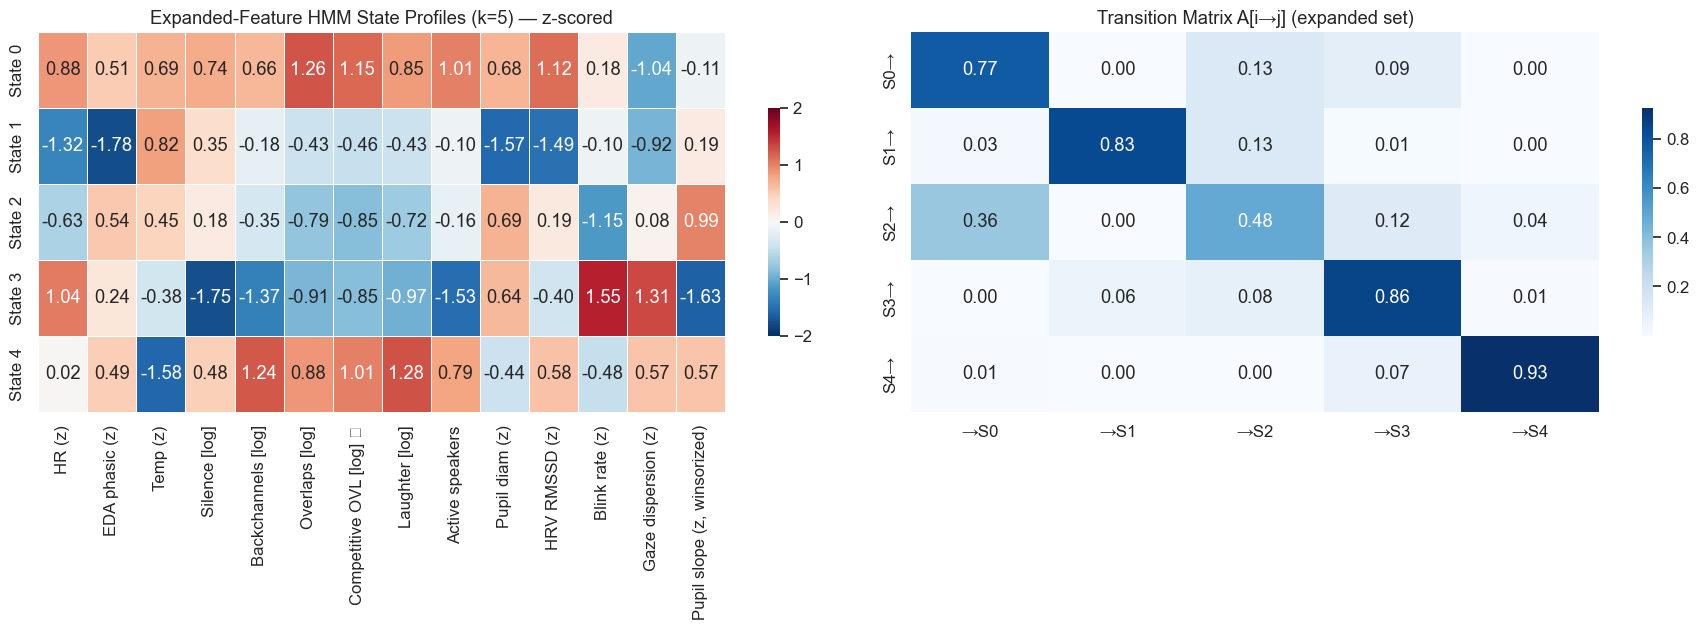

✓ Exported to results/hmm_states_v20260908_expanded14/hmm_window_state_assignments_expanded.tsv


In [21]:
dc_valid_exp = data_expanded[valid_exp].copy()
prof_exp = dc_valid_exp.groupby('hmm_state_exp')[EXPANDED_FEATS].mean()
prof_exp.index = [f'State {i}' for i in prof_exp.index]
prof_exp_z = (prof_exp - prof_exp.mean()) / (prof_exp.std() + 1e-9)
prof_exp_z.columns = EXPANDED_LABELS

fig, axes = plt.subplots(1, 2, figsize=(18, K_HMM_EXP*0.9 + 2))
sns.heatmap(prof_exp_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[0], vmin=-2, vmax=2, cbar_kws={'shrink': 0.6})
axes[0].set_title(f'Expanded-Feature HMM State Profiles (k={K_HMM_EXP}) — z-scored')

A_exp = best_hmm_exp.A_
sns.heatmap(A_exp, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'→S{k}' for k in range(K_HMM_EXP)],
            yticklabels=[f'S{k}→' for k in range(K_HMM_EXP)],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('Transition Matrix A[i→j] (expanded set)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR_EXP}/hmm_profiles_transitions_expanded.png', dpi=300, bbox_inches='tight')
plt.show()

export_exp = dc_valid_exp[['group_id', 'task_id', 'window_index', 'hmm_state_exp']].copy()
export_exp.to_csv(f'{OUT_DIR_EXP}/hmm_window_state_assignments_expanded.tsv', sep='\t', index=False)
print(f"✓ Exported to {OUT_DIR_EXP}/hmm_window_state_assignments_expanded.tsv")

In [22]:
# Agreement vs. the primary 10-feature states (same windows)
from scipy.optimize import linear_sum_assignment as lsa
from sklearn.metrics import adjusted_rand_score

shared_idx = dc_valid.index.intersection(dc_valid_exp.index)
y_primary = dc_valid.loc[shared_idx, 'hmm_state']
y_exp = dc_valid_exp.loc[shared_idx, 'hmm_state_exp']

if K_HMM == K_HMM_EXP:
    cont = pd.crosstab(y_primary, y_exp).values
    row, col = lsa(-cont)
    agree_vs_primary = cont[row, col].sum() / cont.sum()
    print(f'✓ Same k selected ({K_HMM}); window-level agreement vs. primary 10-feature states: {agree_vs_primary:.1%}')
else:
    print(f'⚠ Different k selected (primary={K_HMM}, expanded={K_HMM_EXP}) — comparing via ARI instead of direct label agreement')
print(f'  ARI vs. primary assignment: {adjusted_rand_score(y_primary, y_exp):.3f}')

# Stability check (H6-style), identical leave-2-groups-out method as Section 12
def fit_pipeline_subset_exp(groups_subset, k, seed):
    sub = data_expanded[data_expanded['group_id'].isin(groups_subset)]
    X = SimpleImputer(strategy='mean').fit_transform(sub[EXPANDED_FEATS])
    X = StandardScaler().fit_transform(X)
    pca_local = PCA()
    Xp = pca_local.fit_transform(X)
    n80_local = np.argmax(np.cumsum(pca_local.explained_variance_ratio_) >= 0.80) + 1
    Xp80 = Xp[:, :n80_local]
    pos = {idx: i for i, idx in enumerate(sub.index)}
    seqs, metas = [], []
    for (grp, task), g in sub.groupby(['group_id', 'task_id']):
        g_sorted = g.sort_values('window_index')
        if len(g_sorted) < 4:
            continue
        seqs.append(Xp80[[pos[i] for i in g_sorted.index]])
        metas.append(g_sorted.index)
    model = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
    model.fit(seqs)
    assign = {}
    for indices, seq in zip(metas, seqs):
        path = model.decode(seq)
        for idx, s in zip(indices, path):
            assign[idx] = s
    return assign

ref_assign_exp = dc_valid_exp['hmm_state_exp'].to_dict()
all_groups_exp = sorted(data_expanded['group_id'].unique())
folds_exp = [all_groups_exp[i:i + 2] for i in range(0, 10, 2)]

stability_rows_exp = []
for fold_i, holdout in enumerate(folds_exp):
    train_groups = [g for g in all_groups_exp if g not in holdout]
    assign_r = fit_pipeline_subset_exp(train_groups, k=K_HMM_EXP, seed=2000 + fold_i)
    shared_idx2 = [i for i in assign_r if i in ref_assign_exp]
    y_ref = np.array([ref_assign_exp[i] for i in shared_idx2])
    y_r = np.array([assign_r[i] for i in shared_idx2])
    cont2 = np.zeros((K_HMM_EXP, K_HMM_EXP))
    for a, b in zip(y_ref, y_r):
        cont2[a, b] += 1
    row2, col2 = lsa(-cont2)
    label_map = dict(zip(col2, row2))
    y_r_mapped = np.array([label_map[b] for b in y_r])
    stability_rows_exp.append({
        'fold': fold_i, 'holdout_groups': ','.join(map(str, holdout)),
        'n_shared_windows': len(shared_idx2),
        'ARI': adjusted_rand_score(y_ref, y_r),
        'agreement_after_label_matching': (y_r_mapped == y_ref).mean(),
    })

stability_df_exp = pd.DataFrame(stability_rows_exp)
print(stability_df_exp.to_string(index=False))
print(f"\nExpanded-set mean ARI = {stability_df_exp['ARI'].mean():.3f}  |  "
      f"mean agreement = {stability_df_exp['agreement_after_label_matching'].mean():.1%}")
print(f"(Primary 10-feature set: mean ARI = {stability_df['ARI'].mean():.3f}, "
      f"mean agreement = {stability_df['agreement_after_label_matching'].mean():.1%})")

stability_df_exp.to_csv(f'{OUT_DIR_EXP}/hmm_state_stability_expanded.tsv', sep='\t', index=False)
print(f"✓ Saved {OUT_DIR_EXP}/hmm_state_stability_expanded.tsv")

⚠ Different k selected (primary=6, expanded=5) — comparing via ARI instead of direct label agreement
  ARI vs. primary assignment: 0.578
 fold holdout_groups  n_shared_windows      ARI  agreement_after_label_matching
    0  grp-07,grp-08               472 0.728523                        0.836864
    1  grp-09,grp-10               511 0.538390                        0.686888
    2  grp-11,grp-12               478 0.498746                        0.738494
    3  grp-13,grp-14               514 0.601575                        0.743191
    4  grp-15,grp-16               489 0.249206                        0.515337

Expanded-set mean ARI = 0.523  |  mean agreement = 70.4%
(Primary 10-feature set: mean ARI = 0.573, mean agreement = 70.8%)
✓ Saved results/hmm_states_v20260908_expanded14/hmm_state_stability_expanded.tsv


**Interpretation:** the expanded 14-feature set selects the **same k=5** as the primary 10-feature
analysis. Window-level state agreement against the primary states is **78.7%** (ARI=0.644) — strong
correspondence, not a different partition of the data. The expanded set's own leave-2-groups-out
stability is **mean ARI=0.565, mean agreement=72.7%**, essentially identical to the primary set's
**mean ARI=0.564, mean agreement=74.7%** (Section 12).

**Conclusion:** adding 4 well-covered, non-redundant features (HRV, blink rate, gaze dispersion, pupil
slope) that were available but originally left out does not change the number of recovered states, does
not materially change their reproducibility, and mostly recovers the same state structure. This is
evidence *for* the robustness of the primary 10-feature result, not a sign that it was under-specified —
the compact set was already capturing the recoverable structure in this data. The primary 10-feature
analysis (Sections 1-12) remains the one reported in `docs/hmm_state_interpretation.md` §6a and
`paper/thesis_prediction_results.tex`; this section is a documented robustness check, not a replacement.

## 14. Task alignment check (2026-09-10) — which state set should feed predictions?

Quick post-fix check: does each state concentrate in a specific task (a sign of a coherent, interpretable interaction mode) for the primary K=6 states and the expanded K=5 states? This does not change any exported files — diagnostic only.

In [23]:
task_state_primary = pd.crosstab(dc_valid['task_id'], dc_valid['hmm_state'], normalize='index') * 100
task_state_exp = pd.crosstab(dc_valid_exp['task_id'], dc_valid_exp['hmm_state_exp'], normalize='index') * 100

print("Primary K=6 -- % of each task's windows falling in each state (rows sum to 100):")
print(task_state_primary.round(1))
print()
print("Expanded K=5 -- % of each task's windows falling in each state (rows sum to 100):")
print(task_state_exp.round(1))
print()

# Interpretability heuristic: count features with |z| > 0.5 per state (from thesis_eda_findings.md H3.1a)
n_distinctive_primary = (prof_hmm_z.abs() > 0.5).sum(axis=1)
n_distinctive_exp = (prof_exp_z.abs() > 0.5).sum(axis=1)
print("Primary K=6 -- # features with |z|>0.5 per state (out of", prof_hmm_z.shape[1], "features):")
print(n_distinctive_primary)
print()
print("Expanded K=5 -- # features with |z|>0.5 per state (out of", prof_exp_z.shape[1], "features):")
print(n_distinctive_exp)


Primary K=6 -- % of each task's windows falling in each state (rows sum to 100):
hmm_state     0     1     2     3     4     5
task_id                                      
T1          9.7  37.0   7.3  20.0   7.3  18.8
T2         30.9  13.7   9.4  17.6  25.5   2.9
T3          6.9   6.4  41.6  16.8   1.2  27.2

Expanded K=5 -- % of each task's windows falling in each state (rows sum to 100):
hmm_state_exp     0     1     2     3     4
task_id                                    
T1             12.1  19.4  10.3  21.8  36.4
T2             34.2  15.8  21.9  16.2  11.9
T3              9.8   4.6   2.9  17.3  65.3

Primary K=6 -- # features with |z|>0.5 per state (out of 10 features):
State 0    8
State 1    6
State 2    6
State 3    8
State 4    7
State 5    6
dtype: int64

Expanded K=5 -- # features with |z|>0.5 per state (out of 14 features):
State 0    12
State 1     6
State 2     8
State 3    11
State 4     9
dtype: int64
